# Machine Learning Neural Net
## Acoustic Anomaly Detection in Machines - MIMII
### Farran Dixon - 33664943


#Abstract

This project undertakes a comprehensive examination of unsupervised acoustic anomaly detection for industrial machines. This model is trained on the MIMII dataset, specifically the fan subset. Similar to the industry and research attempts at acoustic anomaly detection, the model is trained on normal audio only and uses reconstruction error to detect anomalous sounds. The error is computed by comparing log-Mel spectrogram segments before and after reconstruction.

The model combines a Transformer encoder to capture short-term spectral patterns with a Temporal Convolutional Network (TCN) for the long-term temporal context. The encoder and tcn are followed by a simple decoder that reconstructs the input. This hybrid architecture is designed to leverage the strong parallel context modelling capabilities of Transformers and the established sequence modelling and stability of dilated convolutional TCNs.

The data is processed into splits separated by unit ID to measure generalisation to unseen machines. Normalisation statistics are taken globally from the normal training data only. Both steps ensure that no data leakage occurs between the training, validation, and test sets.

The model encodes sliding-window spectrograms of 128 Mel bands at a sampling rate of 16kHz. The error is aggregated back into percentile pooled file-level scores. The model can be observed steadily converging based on reconstruction and demonstrates discriminative ROC/PR behaviour. However, the model highlights limitations due to cross-unit domain shift and a lack of data, a commonly documented issue in prior MIMII/DCASE studies.


#Problem Overview

The goal of the model is to detect abnormal machine sounds by training it to reconstruct normal audio accurately and flag high reconstruction errors as anomalous sounds. The plan mirrors many DCASE/MIMII research studies where only normal data is used for training, and anomaly scores only come from reconstruction error (Koizumi et al., 2021).

The adoption of acoustic anomaly detectors inside industrial settings could reduce cost and downtime. Industrial failures are costly and time-consuming, whereas microphones are cheap and easy to install. The MIMII dataset was constructed to encourage research into machine condition monitoring, including different SNRs and machine variations to promote generalisation to unseen machinery and recording environments.

Method:
 - Sound is represented in Log-Mel spectrograms that are 128 mels @ 16kHz. This is common for anomalous sound detection and the starting point of lots of DCASE/MIMII baselines.

 - The architecture is made of 3 parts: The transformer encoder for parallel self-attention, a TCN for dilated causal convolutions, and a decoder for reconstruction. The transformer was chosen due to its exceptional ability to capture local and global dependencies. The TCN was chosen over an RNN because it offers a longer effective memory and more stable gradients (Bai et al., 2018).

 - The training objective was to minimise MSE reconstruction loss on regular segments and then test on both. At the testing phase, a high reconstruction error indicates an anomaly. This follows DCASE baselines and several attempts at autoencoder solutions for the same sound detection problems.

 - Training, validation, and testing are performed on different fan unit IDs. The disjoint between the sets is designed to check domain shift across fan IDs and test model generalisation.

The rationale behind the unsupervised design is influenced strongly by data and label scarcity. In application, as well as in the DCASE and MIMII baselines, there is a significant imbalance in data between normal and abnormal recordings. There are limited domains to train the model on, which hinders generalisation. Supervised learning requires significantly more labelled data to achieve high generalisation to unseen units.



#Dataset

The Malfunctioning Industrial Machine Investigation and Inspection dataset (MIMII) was used to train the model. It contains thousands of real factory recordings of fans, valves, pumps, and slide rails. Each machine has several different units, all with normal and abnormal labelled recordings across a range of signal-to-noise ratios. In this assignment, only the fan subset is used.

The MIMII dataset was chosen because it was designed specifically for machine condition monitoring (Purohit et al., 2019). It contains unit variability, realistic noise, and multiple machines, all of which are perfect for exposing the model's ability to generalise, or not.

Data preprocessing:
 - Audio is segmented, converted to mono audio, and collapsed into 128 mel, 16kHz log-Mel spectrograms.

Splits:
 - The data is split by unit ID. MIMII has four fans: two are used for training, one for validation, and one for testing.
 - Training is done on normal sounds only, whereas validation and testing have both normal and abnormal sounds. This design choice was influenced by the common MIMII and DCASE evaluation protocol to test unseen domain performance.

The normalisation statistics are computed from the regular training set only. The normalisation is applied to val and test. Computing only on normal training data should avoid accidental data leakage.



# Dataset Structure Diagram

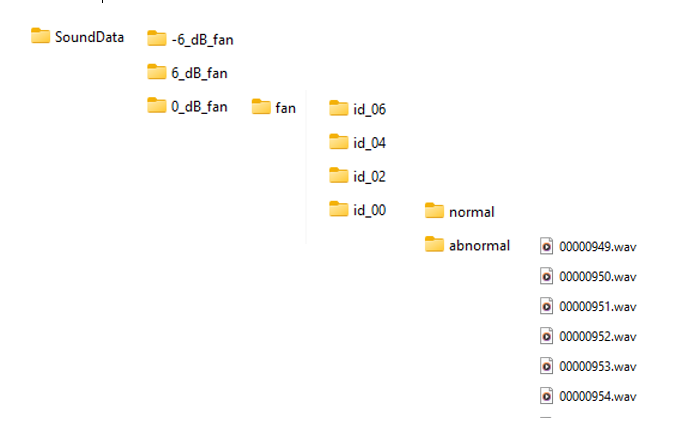

#Model Architecture Diagram

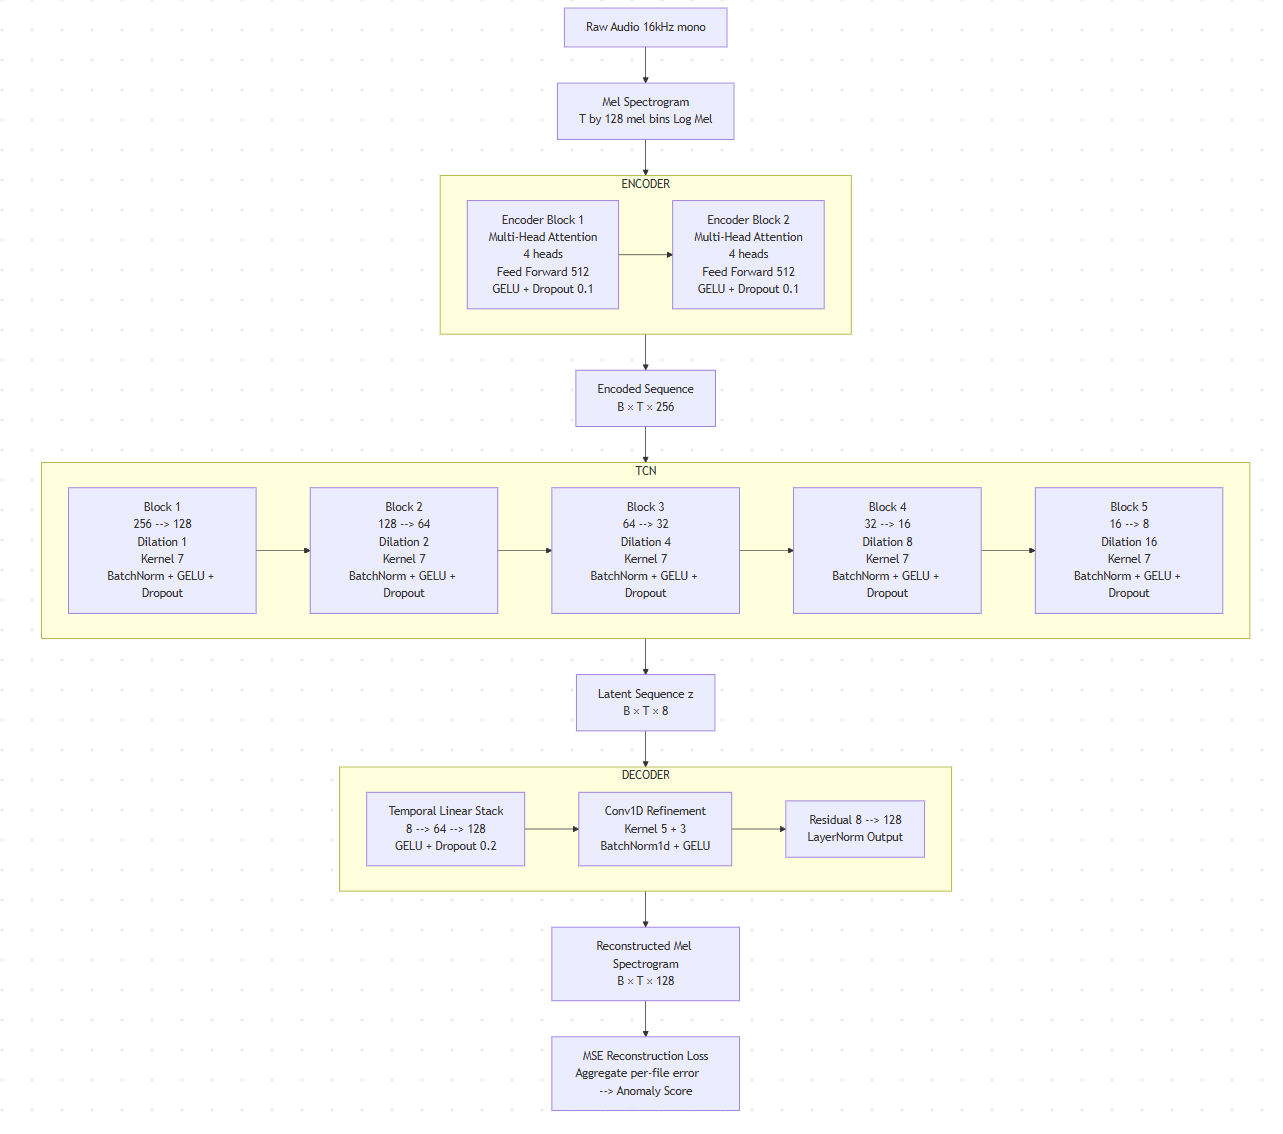



#Performance Curves

## Training and Validation Loss

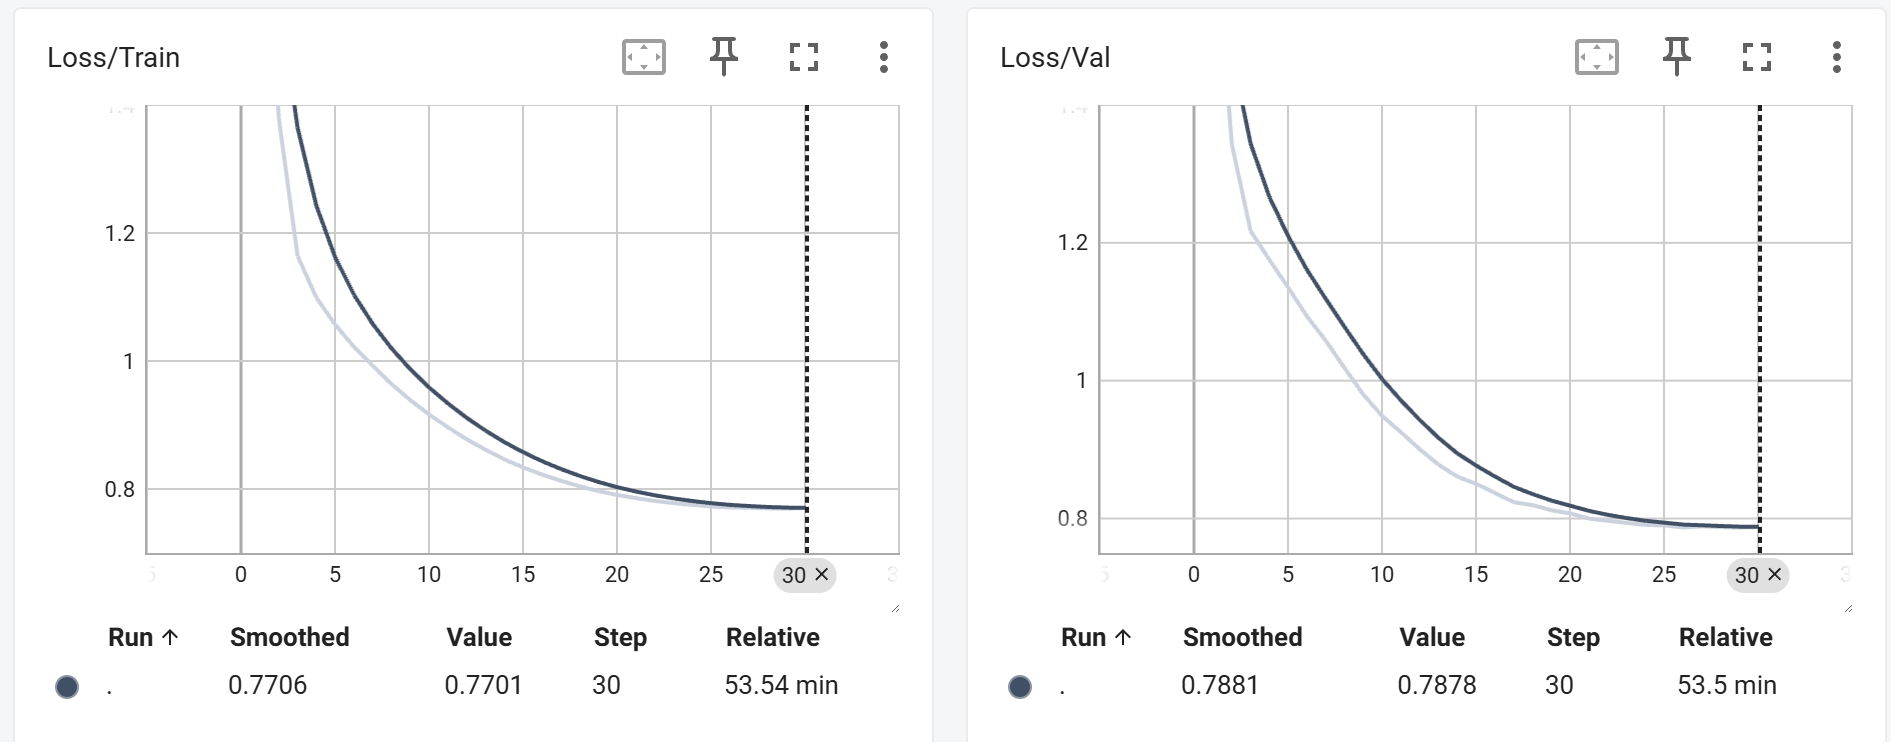


###Loss Curves
Training and Validation reconstruction loss converges smoothly from 1.9 to 0.77 without fluctuation, confirming the model can learn in a stable manner. The difference between training and validation loss as training progresses implies the model does not overfit, but instead underfits due to limited capacity and can't represent complex spectral details. The curves demonstrate steady improvement up to epoch 25 where the performance plateaus strongly, directly proportional to the learning rate decay of the cosine scheduer.

##Validation Metrics - AUC, AUPR, F1, Accuracy

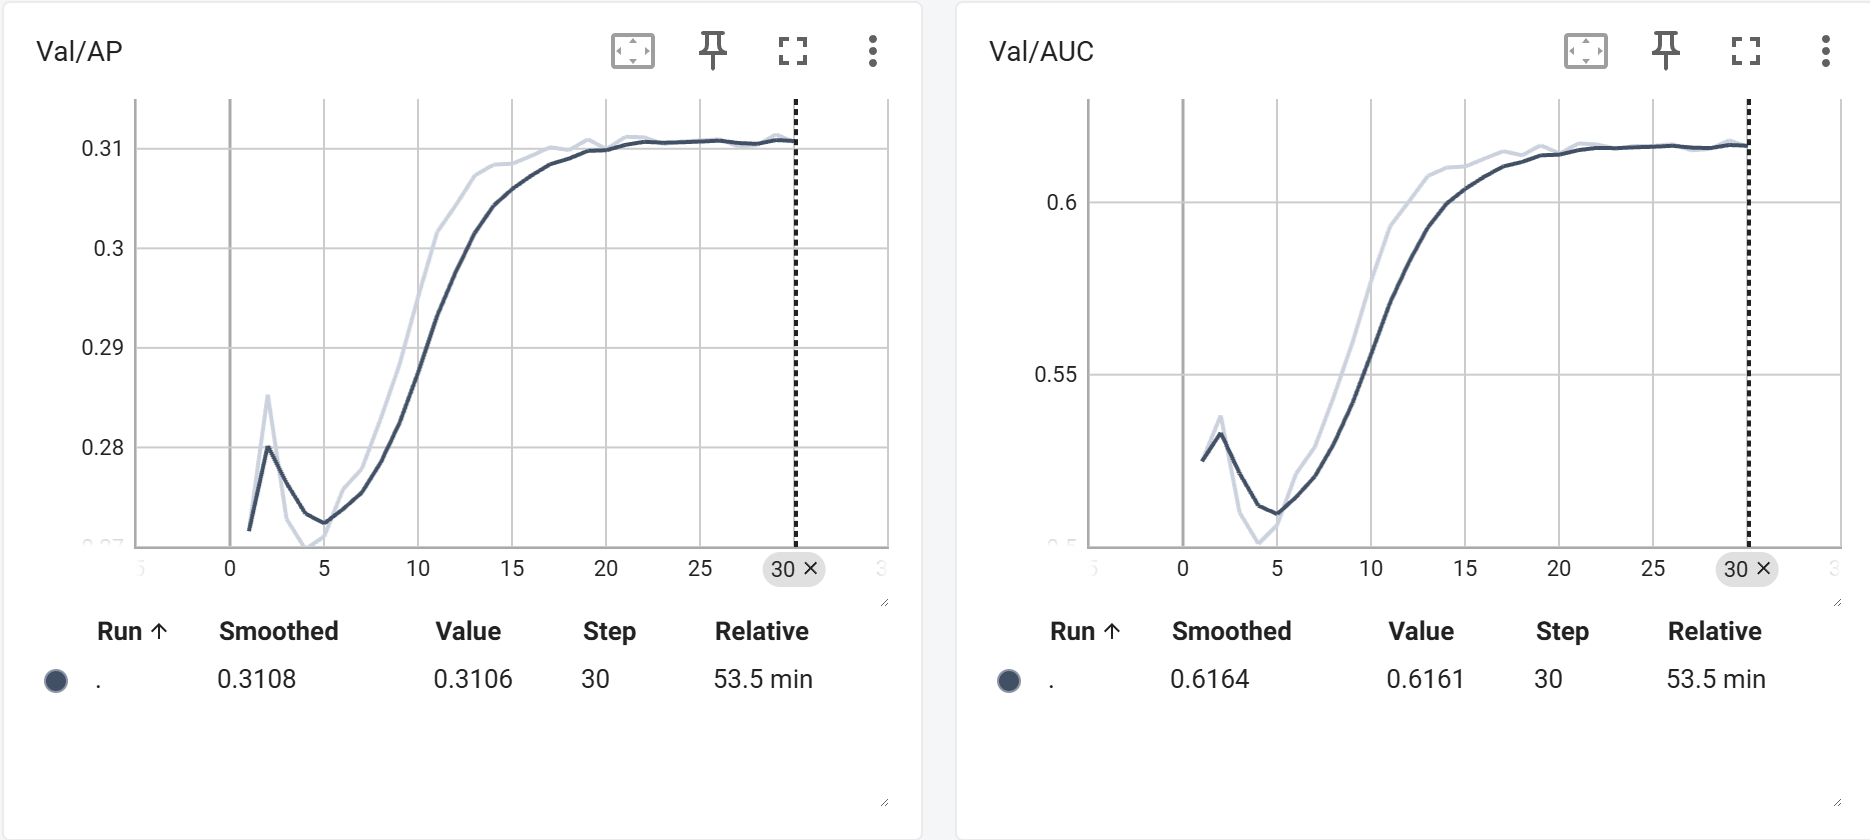

###AUC(ROC):
Area under the ROC curve. AUC is a metric that measures how often the model ranks an abnormal sound higher than a normal sample, at random this is around 0.5, whereas perfect classiciation is a full 1.0.

The model shows a best validation AUC of 0.62, which shows the model learned a weak but meaningful separation. The drop in AUC during testing represents the cross-unit generalisation failure common in MIMII due to vast imbalances in the dataset.

###Area Under the Precision-Recall Curve (AUPR)
AUPR is a measure of how accuratly the detector indentifies rare anomalies, it is highly sensitive to class imbalance. The model achieved an AUPR of 0.31, showing the model performs above a baseline of 0.2, confirming the models ability to detect some true anomalies, but is indicative of many false positive on unseen units.




###Validation Accuracy and F1 Score

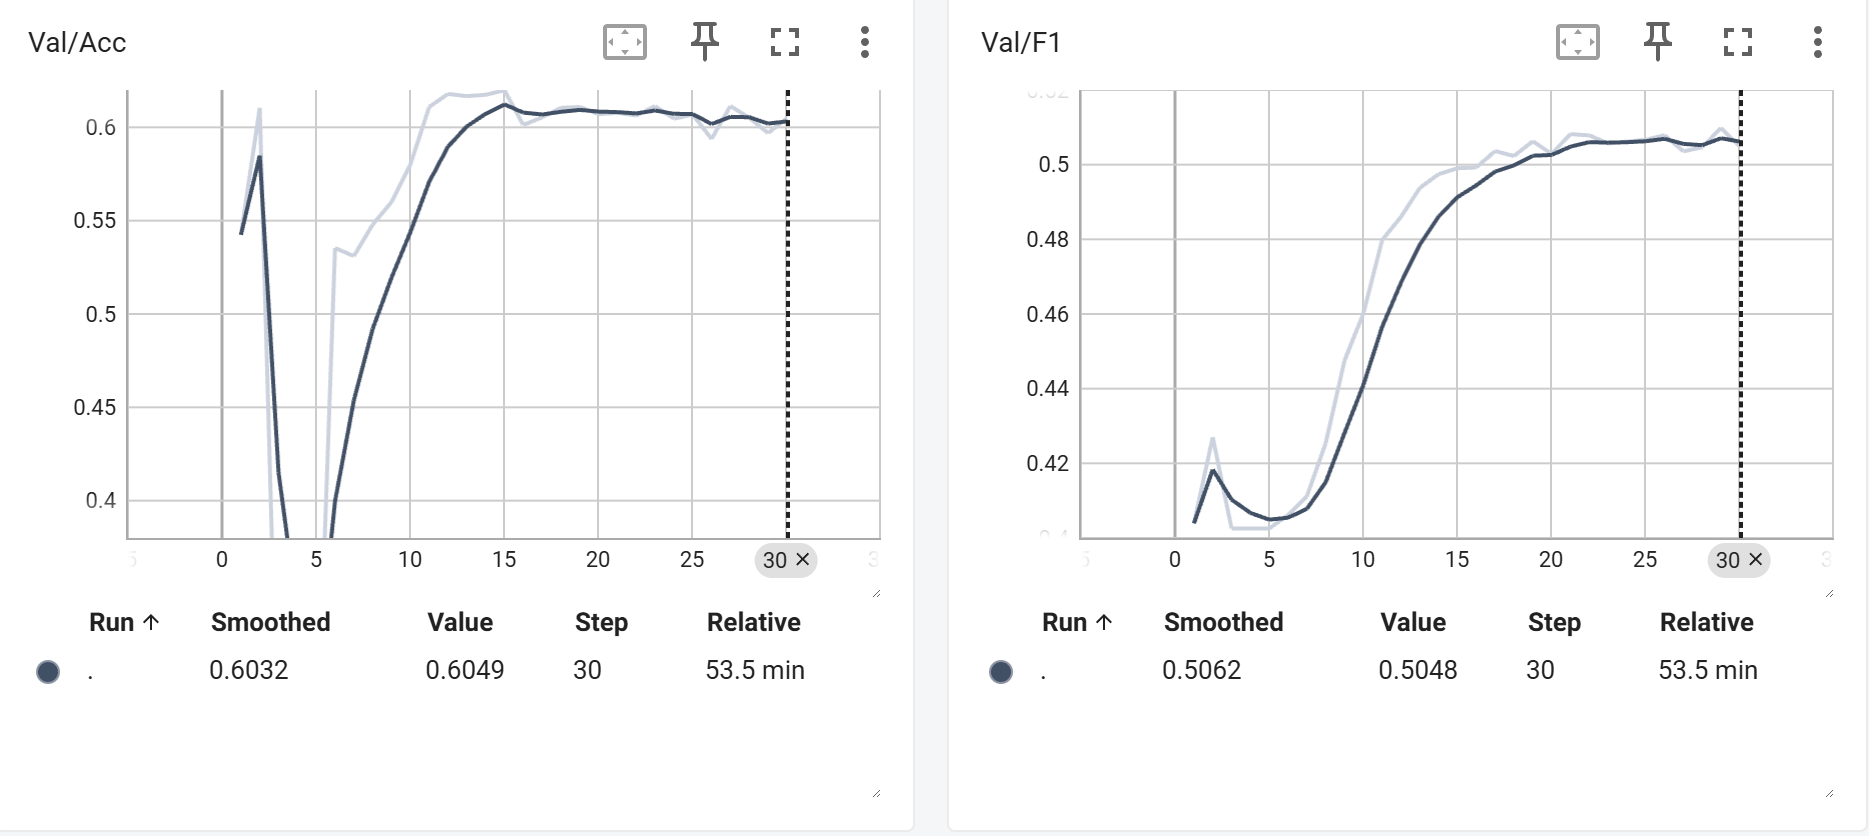


###F1 Score
F1 score is a metric indicating the balance between precision and recall. The model achieved an F1 of 0.5 during validatoin, showing it correctly identified only half of the anomalies as anomalies (see confusion matrix).


###Validation Accuracy
This metric isn't very useful for this task. Anomaly reconstruction should result in MSE error, hurting the validation accuracy.

## Confusion Matrix

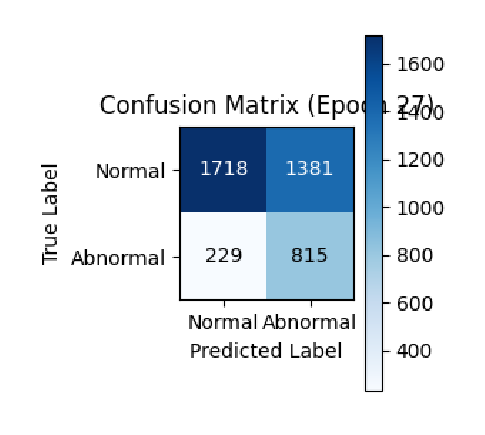


###Confusion Matrix
The confusion matrix demonstrates clearly the model's decion balance. It detects lots of true anamalies but confuses volatile or noisy normal samples.



## Reconstruction Visualisation

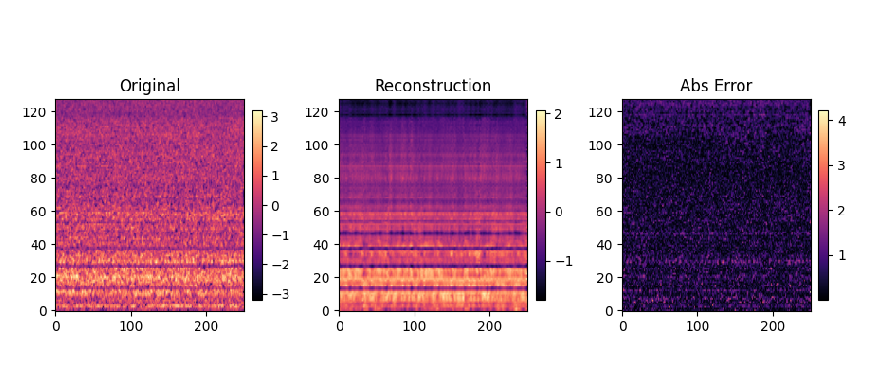

###Reconstruction Visualisation
This display shows that many high freqency transients and subtle harmonics are badly reconstructed, resulting in low contrast between normal and abnormal error maps.


#Discussion - Design Rationale

Industrial and machinery faults tend to be subtle, infrequent, or varied, making the collection of balanced, labelled data very challenging. The model architecture is designed to function despite massive data imbalance by training only on normal audio and using reconstruction error during testing as the anomaly score. Early DCASE and MIMII auto-encoder-based acoustic anomaly detection models influence the design. The AE-based models employ the same training and anomaly scoring rationale on reconstructed mel-spectrograms, where normal sounds yield low error and abnormal sounds result in high error. The MIMII dataset is well-established for this task, as it targets only machines with both regular and anomalous recordings in realistic conditions.

To prevent data leakage, ,the dataset was devided by machine unit ID, rather than by individual audio files.
  - Training units: ID_00, ID_06 (normal data only)
  - Validation unit: ID_04 (normal and abnormal data)
  - Test unit: ID_02 (normal and abnormal, unseen in training)

The seperation ensures that each subset represents a seperate fan. The split enforces domain shift generalisation to unseen instances rather than simple pattern recognition.

The model was trained for 30 epochs using a Transformer Encoder, a TCN, and a fully connected decoder architecture. The model was optimised with AdamW with a cosine-annealing learning rate scheduler.



##Front End:

The data comes in the form of 16kHz mono waveforms. The data is converted to mel-spectrograms (mel-filterbank magnitudes represented in decibels). Mel features compress wideband audio into an image in the shape of time x frequency. The spectrogram captures the spectral envelopes and tonal bands commonly found in machine acoustics.

Mel spectrograms are the default input for many acoustic sound detectors and speech models due to their ability to conserve spectral patterns that appear in the ambiguous acoustic structure. The spectrogram reduces the dimensionality of the raw waveforms, enabling the local 2D structure for the convolutional and attention models to utilise.


##Encoder:

The encoder is based on the transformer encoder-decoder architecture, with only the encoder side (Vaswani et al., 2017). It is used as a replacement for the autoencoder usually seen in ASD tasks, designed to capture short and mid-term temporal context information (Kawaguchi et al., 2019). The transformer encoder stores each time step's mel vector into a numerical embedding, adds positional encoding, and stacks multi-head self-attention blocks together. The self-attention ability enables dependencies to be learned across time without repetition, picking up periodicities, harmonics, and transient bursts that symbolise machine condition. It is powerful because it can cope with variable context and can relate non-adjacent frames. The choice of transformer encoder was made because it has become a standard in sequence modelling, owing to its parallelism and long-range modelling ability.


##Middle temporal modelling:

The TE passes its output sequence to the middle of the model, the Temporal Convolutional Network (TCN). The TCN is built from dilating 1D residual blocks. The design ideally models medium- to long-range temporal patterns in the spectrogram's domain to capture slowly evolving or quasi-stationary patterns.

The dilated convolutions increase the receptive field exponentially as depth increases, meaning only a small number of stacked layers is needed to review acoustic context across hundreds of frames (seconds) without loss of temporal resolution. This lightweight, long-term feature modelling is necessary for machinery sounds that have periodic cycles and gradually evolving operating state transitions. The hierarchical nature of the receptive field is designed to enable the model to detect both fast and slow transients across a wide range of machine noises.

The TCN is equipped with a residual connection that enables gradients to flow through the convolutional stacks. The design choice aimed to preserve an acceptable level of spectral/temporal detail that would otherwise be lost through successive convolutions.

TCNs have become standard and recognised backbones for sequence modelling tasks because they combine long receptive fields, parallel processing, and training stability. They have been shown to match or outperform recurrent architectures (LSTM) when doing temporal reasoning, all whilst training faster and avoiding the vasnishing gradient problems (Bai, Kolter & Koltun (2018)). TCN's have already been succesfully applied to audio tasks such as speech sepration, acoustic sound detection, and machine sound modeling, most demonstrating a strong ability to generalise to unseen data.

The TCN and Transformer work together to capture both pattern-level dependencies with attention and stationary temporal regularities with convolutions, a theoretically effective combo for acoustic anomaly detection.

The output of the TCN is deliberately bottlenecked to enforce a low channel latent sequence that represents a compact summary of each frame. The reduced latent space is designed to act as an information filter, encouraging the model to retain only the necessary acoustic signatures of everyday sounds. The compression enforces a dimensionality constraint similar to the classical autoencoder approach, aiming to limit the model's ability to memorise training data. Forcing reconstruction from the small latent space should encourage the decoder to learn generalisable structures, such as harmonic and noise patterns. The latent dimensionality chosen in the model (8) was chosen empirically. 32 allowed the decoder to overfit and reproduce any input perfectly. 4 was too narrow, and the model lost the ability to represent normal variability.

##Decoder
The decoder reconstructs the input mel-spectrogram sequence from the reduced latent representation provided as output by the TCN. It consists of three parts: a temporal fully connected projection, a 1D convolutional refinement block, and a residual shortcut connection to aid in reconstruction after convolution.

The MLP is a temporal MLP that operates independently at each time step. The component expands the latent features into a richer intermediate representation. After normalisation, the output is passed through a stack of 1D convolutions to capture mid-range temporal structure, and another convolution to project the features to the target Mel dimension of 128. The convolutional layers aim to reconstruct spectral details that the MLP cannot do alone. The residual path prevents the gradients from vanishing and encourages the network to learn input latent sequences rather than reconstructing the full sequence.

##Loss Function and Anomaly Scoring

The model utilises the Mean Squared Error (MSE) loss function to measure the discrepancy between the input and the reconstruction. At inference time, per-segment MSE is used as a scalar anomaly score where normal segments produce low errors, and abnormal ones produce high errors. The scores are then aggregated back into file-level metrics (post-segmentation). This file-level aggregation of error scores aligns with official DCASE and MIMII evaluation runs, where the reconstruction error distributions are computed into ROC-AUC, PR-AUC, and F1@threshold scores.


#Discussion - Analysis of Limitations and Failure Cases

##Latent Space Compression

The bottlenecked latent representation has only eight channels, which enforces firm compression to encourage generalisation, but is too narrow to represent the spectral variability of real machine noises properly. A small latent space helps prevent overfitting to normal data, but it also restricts the model's ability to represent legitimate data in normal operating conditions. The result is that the training loss steadily decreases, but the validation loss plateaus early, and reconstruction quality on both normal and abnormal samples is terrible, leading to a stagnated error distribution and making the contrast between normal and abnormal samples negligible. A possible fix is to increase the latent width to preserve low-level information, if generalisation can be improved.

##Normalisation mismatch.

The model utilises BatchNorm1d within the TCN blocks. BatchNorm stats depend heavily on batch composition. As the normalisation stats are computed on training IDs only, the distribution of training and validation samples differs. The result is that the validation AUC varies strongly across units; some units perform acceptably, whereas others collapse to near-random scoring error. This pattern is indicative of a domain-shift sensitivity problem rather than an inability to learn features. The mismatched statistics distort feature scaling, causing unstable reconstructions and inconsistent anomaly scoring. This issue could be addressed by replacing BatchNorm with LayerNorm or GroupNorm in the TCN for improved adaptation to domain variance.

##Data Windowing and Evaluation Inconsistency

During training, files are segmented into a sliding window with a set overlap. The aim was not only to increase the available training data but also to align it with how the model would listen in application. Evaluation used full clips with no segmentation. The difference changes the context length and the temporal statistics the model sees. This caused the reconstruction error of each segment to vary wildly, resulting in noisy validation metrics and unstable thresholding for decision-making. The shorter windows during training produce overlapping and repetitive patterns that may not be present during longer, non-overlapping evaluation windows. Similar to DCASE practice, the per-segment statistics were aggregated back to the file level using the 95th percentile before computing the metric.

##Dataset Limitations

The MIMII fan dataset is widely used for acoustic machine learning, but it is designed to introduce a few constraints that limit performance. There is a massive data imbalance, only a few abnormal recordings per unit, and the faults are not clearly labelled. Some anomalies appear as no more than subtle mechanical deviations rather than distinct failures, which cause reconstruction error targets to be noisy. The dataset is recorded in different acoustic environments, and signal-to-noise ratios can vary. This dynamic background noise can interfere and present as an actual anomalous fault signature.

Training, validation, and test splits represent different physical machines (unit ID). It is designed to directly test the model's ability to generalise to unseen units. The dataset, which only contains 4 unit IDs, is tiny for training the model to generalise across something as ambiguous as fans. The model sees two units in training, one in validation, and one in test, limiting domain variability and necessitating generalisation, not pattern recall. The model realistically needs far more normal data across various domains to learn to generalise properly to unseen cases.

These factors combined make he dataset very non-IID. It is not independent, as each training sample is related to the others. Additionally, samples do not come from the same underlying probability distribution.


##Decoder Capacity and Reconstruction Quality

The decoder is designed to be lightweight and efficient, ensuring optimal performance. However, the lack of parameters limits spectral fidelity, forcing reconstructions to appear soft and blurred rather than precise, which indicates that the model cannot accurately discern what is happening after the bottleneck. Increasing the number of MLP layers may help by increasing spectral resolution without requiring a large number of parameters.


## Supervised Variant Failure Case

Initially, this model was designed as a supervised binary classification model. It was trained directly using binary cross-entropy loss on normal versus abnormal samples. The model achieved infrequent and very momentary improvements in training accuracy but displayed explosive validation loss and volatile AUC curves. The labelled dataset is highly imbalanced, causing the classifier to overfit normal patterns and treat minor anomalies as simple noise. The inconsistency of this supervised version necessitated a switch to unsupervised learning, which is still imperfect, but avoids the dependency on fault labels.


##Other Limitations
 - Resource Usage: The transformer encoder increases training time and GPU memory, which limits the empirical hyperparameter exploration.

 - Feature representation: Fixed log-mel spectrograms sometimes do not capture all fault-specific information.

 - Evaluation scope: Experiments focused on one machine type; generalisation to other MIMII categories is untested.

 - Limitations collectively explain why reconstruction-based models, while theoretically strong to label scarcity, still struggle with generalisation barriers when trained on small, non-IID industrial datasets.















#Conclusion

Ultimately, the model failed to demonstrate strong anomaly detection performance. It achieved barely moderate validation results, poor generalisation to unseen units, and showed signs of underfitting. Despite the low scores, the project successfully demonstrated a complete, working deep-learning framework, highlighted the difficulty of unsupervised acoustic anomaly detection compared to conventional supervised tasks, and showed just how important clean, labelled data is to deep learning models.

#Source Code and Dataset Download Code

In [5]:
import os, sys, zipfile, warnings

try:
    import gdown
except ImportError:
    !pip install -q gdown
    import gdown

urls = {
    "src": "https://drive.google.com/uc?id=1CK4vr1PXvsMg83pApHW9slcyxUzMMRKo",
    "SoundData": "https://drive.google.com/uc?id=1pX_CzpmWCScD8p82P1uemooZlBOzfCQk"
}
targets = {"src": "src.zip", "SoundData": "SoundData.zip"}


def safe_extract(zip_path, extract_to):
    if not os.path.exists(zip_path):
        print(f"File not found: {zip_path}")
        return
    print(f"Extracting {zip_path} -> {extract_to}")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(extract_to)
    print("Extraction complete.")


for key, url in urls.items():
    out = targets[key]
    print(f"\nDownloading {key} from:\n{url}\n-> {out}")
    try:
        gdown.download(url, out, quiet=False)
    except Exception as e:
        warnings.warn(f"Download failed for {key}: {e}")
        continue

print("\nDirectory contents:")
for f in os.listdir("."):
    if os.path.isdir(f):
        print(f)



https://drive.google.com/uc?id=1CK4vr1PXvsMg83pApHW9slcyxUzMMRKo
-> src.zip


Downloading...
From: https://drive.google.com/uc?id=1CK4vr1PXvsMg83pApHW9slcyxUzMMRKo
To: /content/src.zip
100%|██████████| 73.3k/73.3k [00:00<00:00, 63.5MB/s]



https://drive.google.com/uc?id=1pX_CzpmWCScD8p82P1uemooZlBOzfCQk
-> SoundData.zip

Directory contents:
.config
src
sample_data


/tmp/ipython-input-4059129148.py:32: UserWarning: Download failed for SoundData: Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1pX_CzpmWCScD8p82P1uemooZlBOzfCQk

but Gdown can't. Please check connections and permissions.
  warnings.warn(f"Download failed for {key}: {e}")


#Run this to add src directory if not in path

In [ ]:
import sys, os
from pathlib import Path

project_root = Path.cwd()
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print("added to path", src_path)
print("working directory:", project_root)

added to path C:\Users\Fazz9\Downloads\Assingment 2 refactor maybe final\Assignment2RefactorUnsupervised\src
working directory: C:\Users\Fazz9\Downloads\Assingment 2 refactor maybe final\Assignment2RefactorUnsupervised


#Main Entry Point - Runs both training and inference

You will need src and SoundData files in the same directory as this workbook.

In [ ]:
from src.main import main
main()

Using device: cuda
[build records] Parsed 16650 files across 4 units.
Example: C:\Users\Fazz9\Downloads\Assingment 2 refactor maybe final\Assignment2RefactorUnsupervised\SoundData\0_dB_fan\fan\id_00\abnormal\00000000.wav -> SNR = 0_dB_fan
[FAN] using fixed split for units
[fan] units = 4 train = 2 val=1 test=1
train=['id_00', 'id_06'] val=['id_04'] test = ['id_02']
[Samples] train=8382  val=4143  test=4125
[SlidingWindow] Generated 16764 segments from 8382 files (hop = 5.0s, overlap=0.00).
[SlidingWindow] Generated 8286 segments from 4143 files (hop = 5.0s, overlap=0.00).
[SlidingWindow] Generated 8250 segments from 4125 files (hop = 5.0s, overlap=0.00).
[Recon Mode] Train filtered to normals -> 6078 records
[SlidingWindow] Generated 12156 segments from 6078 files (hop = 5.0s, overlap=0.00).
Train level distribution: Counter({0: 6078})
Global (weighted) mean/std shapes: torch.Size([128]), torch.Size([128])
tensor(-21.9327) tensor(8.2889) tensor(5.5842) tensor(0.8577)

 --- Split Integr

#References

  - Bai, S., Kolter, J. Z., & Koltun, V. (2018). An empirical evaluation of generic convolutional and recurrent networks for sequence modeling. arXiv preprint arXiv:1803.01271. https://arxiv.org/abs/1803.01271

  - Koizumi, Y., Purohit, H., Tanabe, R., Kawaguchi, Y., Harada, N., & Imoto, K. (2021). Description and discussion on DCASE 2021 challenge task 2: Unsupervised anomalous sound detection for machine condition monitoring under domain shifted conditions. DCASE 2021 Challenge. https://dcase.community/challenge2021/task-unsupervised-detection-of-anomalous-sounds

  - Purohit, H., Tanabe, R., Koizumi, Y., Harada, N., & Kawaguchi, Y. (2019). MIMII dataset: Sound dataset for malfunctioning industrial machine investigation and inspection. In Proceedings of the Detection and Classification of Acoustic Scenes and Events (DCASE) Workshop 2019 (pp. 209–213). https://arxiv.org/abs/1909.09347

  - Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). Attention is all you need. Advances in Neural Information Processing Systems, 30 (NeurIPS 2017). https://arxiv.org/abs/1706.03762

  - Kawaguchi, Y., Tanabe, R., & Koizumi, Y. (2019). Anomaly detection based on an ensemble of autoencoders and Gaussian mixture models. In Proceedings of the Detection and Classification of Acoustic Scenes and Events (DCASE) Workshop 2019. https://dcase.community/documents/workshop2019/proceedings/DCASE2019Workshop_Kawaguchi_Ensemble.pdf

  - Bai, S., Kolter, J. Z., & Koltun, V. (2018). An empirical evaluation of generic convolutional and recurrent networks for sequence modeling. arXiv preprint arXiv:1803.01271. https://arxiv.org/abs/1803.01271